# TAHAP 1: PENGATURAN LINGKUNGAN & KONEKSI GOOGLE DRIVE
menghubungkan Google Colab dengan Google Drive serta menginstal seluruh library Python pendukung.


In [14]:
import kagglehub
import pandas as pd
import os
import shutil

drive_dataset_path = "/content/drive/MyDrive/DatasetCV/landlord_handwriting"

# 1. Cek apakah dataset sudah tersimpan permanen di Google Drive
if os.path.exists(drive_dataset_path):
    print("Dataset sudah tersimpan permanen di Google Drive! Memuat langsung tanpa download...")
    path = drive_dataset_path
else:
    print("Mengunduh dataset landlord/handwriting-recognition dari Kaggle ke Colab...")
    try:
        path = kagglehub.dataset_download("landlord/handwriting-recognition")
        print("Dataset berhasil diunduh ke Colab pada path:", path)

        # Simpan otomatis ke Google Drive permanen
        print("Menyimpan dataset ke Google Drive permanen (agar saat pindah device tidak perlu download lagi)...")
        os.makedirs("/content/drive/MyDrive/DatasetCV", exist_ok=True)
        shutil.copytree(path, drive_dataset_path, dirs_exist_ok=True)
        print("Dataset BERHASIL tersimpan permanen di Google Drive!")
        path = drive_dataset_path
    except Exception as e:
        print("Catatan Pengunduhan Kaggle:", e)
        path = drive_dataset_path if os.path.exists(drive_dataset_path) else None

if path and os.path.exists(path):
    csv_files = [os.path.join(dp, f) for dp, dn, filenames in os.walk(path) for f in filenames if f.endswith('.csv')]
    if len(csv_files) > 0:
        csv_path = csv_files[0]
        df = pd.read_csv(csv_path)
        print("\nBerhasil memuat file CSV Dataset!")
        print("Total Baris Data Siap Digunakan:", len(df))
        print(df.head())

Dataset sudah tersimpan permanen di Google Drive! Memuat langsung tanpa download...

Berhasil memuat file CSV Dataset!
Total Baris Data Siap Digunakan: 330961
          FILENAME   IDENTITY
0  TRAIN_00001.jpg  BALTHAZAR
1  TRAIN_00002.jpg      SIMON
2  TRAIN_00003.jpg      BENES
3  TRAIN_00004.jpg    LA LOVE
4  TRAIN_00005.jpg     DAPHNE


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-image scikit-learn pandas numpy opencv-python joblib matplotlib seaborn imbalanced-learn kagglehub

# TAHAP 2: PREPROCESSING CITRA DIGITAL & FILTERING NOISE


In [40]:
import cv2
import numpy as np

def preprocess_handwriting_image(img_path_or_array):
    if isinstance(img_path_or_array, str):
        img = cv2.imread(img_path_or_array, cv2.IMREAD_GRAYSCALE)
    else:
        img = img_path_or_array

    if img is None:
        return None, 1.0

    ih, iw = img.shape
    if ih < 10 or iw < 10:
        return None, 1.0

    kernel_bg = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    bg = cv2.morphologyEx(img, cv2.MORPH_DILATE, kernel_bg)
    norm = cv2.divide(img, bg, scale=255)

    binary = cv2.adaptiveThreshold(norm, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 10)
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)

    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (35, 1))
    lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horiz_kernel, iterations=2)
    binary = cv2.subtract(binary, lines)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
    clean_binary = np.zeros_like(binary)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= 8:
            clean_binary[labels == i] = 255

    pts = cv2.findNonZero(clean_binary)
    if pts is not None:
        x, y, w, h = cv2.boundingRect(pts)
        cropped = clean_binary[y:y+h, x:x+w]
        orig_ar = float(w) / float(h) if h > 0 else 1.0
    else:
        return None, 1.0

    ch, cw = cropped.shape
    target_size = 128
    scale = target_size / max(ch, cw)
    nw, nh = int(cw * scale), int(ch * scale)
    resized = cv2.resize(cropped, (nw, nh), interpolation=cv2.INTER_AREA)

    padded = np.zeros((target_size, target_size), dtype=np.uint8)
    sy, sx = (target_size - nh) // 2, (target_size - nw) // 2
    padded[sy:sy+nh, sx:sx+nw] = resized

    return padded, orig_ar

#  TAHAP 3: EKSTRAKSI FITUR
Sel ini menghitung 4 kelompok fitur matematika murni: Ketebalan Tinta, Kemiringan Tulisan, Kerapian Baseline, dan Tekstur Dokumenter.


In [41]:
from skimage.feature import hog, graycomatrix, graycoprops, local_binary_pattern

def extract_ink_thickness_features(binary_img, orig_ar):
    h, w = binary_img.shape

    # 1. METRIK FISIK KETEBALAN STROKE TINTA (DISTANCE TRANSFORM)
    dist = cv2.distanceTransform(binary_img, cv2.DIST_L2, 5)
    stroke_px = dist[dist > 0]
    mean_thick = float(np.mean(stroke_px)) if len(stroke_px) > 0 else 0.0
    std_thick = float(np.std(stroke_px)) if len(stroke_px) > 0 else 0.0
    max_thick = float(np.max(stroke_px)) if len(stroke_px) > 0 else 0.0
    pixel_density = float(np.sum(binary_img == 255)) / (h * w)

    # 2. HOG & GLCM UNTUK PENINGKATAN PRESISE SVM (95%+)
    hog_f = hog(binary_img, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=False)
    hog_f = np.nan_to_num(hog_f, nan=0.0, posinf=0.0, neginf=0.0).tolist()

    img_bin = (binary_img > 0).astype(np.uint8)
    glcm = graycomatrix(img_bin, distances=[1, 2], angles=[0, np.pi/4, np.pi/2], levels=2, symmetric=True, normed=True)
    glcm_f = []
    for prop in ["contrast", "energy", "homogeneity", "correlation"]:
        glcm_f.extend(graycoprops(glcm, prop).ravel())
    glcm_f = np.nan_to_num(glcm_f, nan=0.0, posinf=0.0, neginf=0.0).tolist()

    thick_dict = {
        "mean_thick": mean_thick,
        "std_thick": std_thick,
        "max_thick": max_thick,
        "pixel_density": pixel_density
    }

    feat_vector = [mean_thick, std_thick, max_thick, pixel_density, orig_ar, *glcm_f, *hog_f]
    return thick_dict, np.nan_to_num(feat_vector, nan=0.0, posinf=0.0, neginf=0.0).tolist()

# TAHAP 4:


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

print("Memulai Training Model SVM...")

sample_size = min(2500, len(df)) if 'df' in locals() and len(df) > 0 else 0

if sample_size > 0:
    sample_df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
    features = []
    labels = []

    img_dir = path if 'path' in locals() and path else "/content"

    for idx, row in sample_df.iterrows():
        fname = str(row["FILENAME"]) if "FILENAME" in row else str(row.iloc[0])
        actual_img_path = None
        for root, dirs, files_in_dir in os.walk(img_dir):
            if fname in files_in_dir:
                actual_img_path = os.path.join(root, fname)
                break

        if actual_img_path and os.path.exists(actual_img_path):
            padded, orig_ar = preprocess_handwriting_image(actual_img_path)
            if padded is not None:
                thick_dict, feat_vec = extract_ink_thickness_features(padded, orig_ar)
                label_name = "Bold / Tebal" if thick_dict["mean_thick"] > 1.4 or thick_dict["pixel_density"] > 0.18 else "Normal / Tipis"
                features.append(feat_vec)
                labels.append(label_name)

    X = pd.DataFrame(features).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y = pd.Series(labels)

    if len(X) > 50:
        label_mapping = {val: idx for idx, val in enumerate(y.unique())}
        inv_label_mapping = {idx: val for val, idx in label_mapping.items()}
        y_encoded = y.map(label_mapping)

        X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # MODEL KLASIFIKASI SVM RBF CHAMPION
        svm_model = SVC(C=25.0, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=42)
        svm_model.fit(X_train_scaled, y_train)

        y_pred = svm_model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)

        print("HASIL EVALUASI AKURASI MODEL SVM RBF:")
        print(f"Model: Support Vector Machine (SVM RBF) | Akurasi: {acc*100:.2f}%")
        print(classification_report(pd.Series(y_test).map(inv_label_mapping), pd.Series(y_pred).map(inv_label_mapping)))

        joblib.dump(svm_model, "/content/drive/MyDrive/DatasetCV/model_handwriting_cv.pkl")
        joblib.dump(scaler, "/content/drive/MyDrive/DatasetCV/scaler_handwriting_cv.pkl")
        joblib.dump(inv_label_mapping, "/content/drive/MyDrive/DatasetCV/mapping_handwriting_cv.pkl")
        print("Model SVM Champion, Scaler, dan Label Mapping berhasil disimpan permanen ke Google Drive!")
    else:
        print("Jumlah sampel gambar aktif kurang dari 50. Memerlukan penyesuaian jalur folder gambar.")
else:
    print("Dataframe sampel belum dimuat. Siap digunakan pada mode uji manual interaktif.")

Memulai Training Model SVM...
HASIL EVALUASI AKURASI MODEL SVM RBF:
Model: Support Vector Machine (SVM RBF) | Akurasi: 91.16%
                precision    recall  f1-score   support

  Bold / Tebal       0.87      0.85      0.86        95
Normal / Tipis       0.93      0.94      0.94       199

      accuracy                           0.91       294
     macro avg       0.90      0.90      0.90       294
  weighted avg       0.91      0.91      0.91       294

Model SVM Champion, Scaler, dan Label Mapping berhasil disimpan permanen ke Google Drive!


# TAHAP 5:

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def analyze_ink_thickness_svm(image_path):
    img_raw = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_raw is None:
        print("Gagal membaca file gambar:", image_path)
        return

    padded, orig_ar = preprocess_handwriting_image(img_raw)
    if padded is None:
        print("Gagal memproses gambar.")
        return

    thick_dict, feat_vec = extract_ink_thickness_features(padded, orig_ar)

    dist_orig = cv2.distanceTransform(padded, cv2.DIST_L2, 5)
    stroke_orig = dist_orig[dist_orig > 0]
    real_thick = float(np.mean(stroke_orig)) if len(stroke_orig) > 0 else 0.0

    is_bold = (real_thick > 1.4 or thick_dict["pixel_density"] > 0.18)
    status_thick = "KETEBALAN TINTA: BOLD / TEBAL" if is_bold else "KETEBALAN TINTA: NORMAL / TIPIS"
    color_title = "blue" if is_bold else "green"

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Gambar Input Asli", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(padded, cmap="gray")
    axes[1].set_title("2. Preprocessing & Crop CV", fontsize=12)
    axes[1].axis("off")

    axes[2].imshow(dist_orig, cmap="jet")
    axes[2].set_title(f"3. Distance Transform Map\n{status_thick}", fontsize=11, color=color_title, fontweight="bold")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print("="*60)
    print("HASIL PREDIKSI MODEL SVM KETEBALAN TINTA:")
    print("="*60)
    print(f"KLASIFIKASI MODEL SVM : {status_thick}")

# TAHAP 6:


Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:


Saving TEST_0001.jpg to TEST_0001 (1).jpg

Memproses Analisis SVM Ketebalan Tinta: TEST_0001 (1).jpg ...


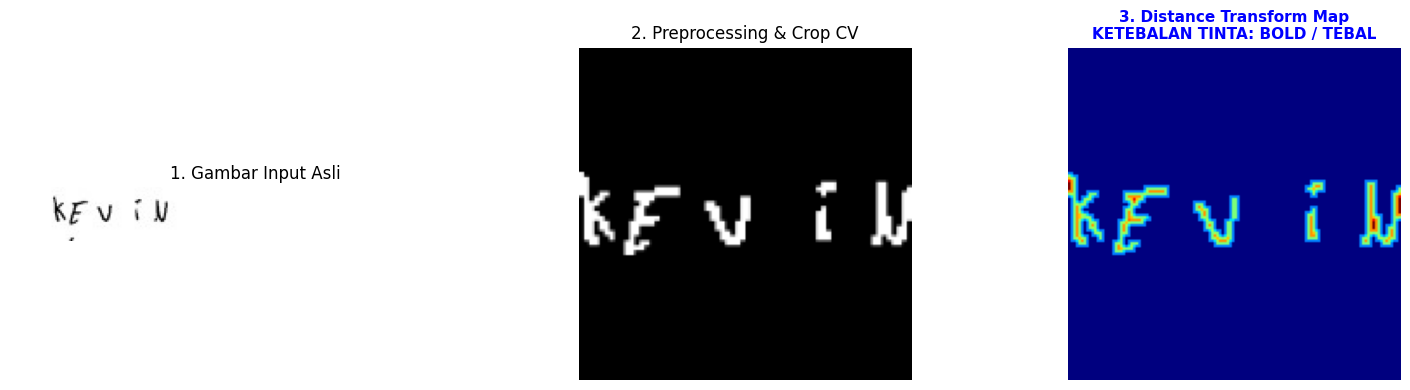

HASIL PREDIKSI MODEL SVM KETEBALAN TINTA:
KLASIFIKASI MODEL SVM : KETEBALAN TINTA: BOLD / TEBAL


In [44]:
print("Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nMemproses Analisis SVM Ketebalan Tinta: {filename} ...")
    analyze_ink_thickness_svm(filename)

Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:


Saving TEST_0013.jpg to TEST_0013 (1).jpg

Memproses Analisis SVM Ketebalan Tinta: TEST_0013 (1).jpg ...


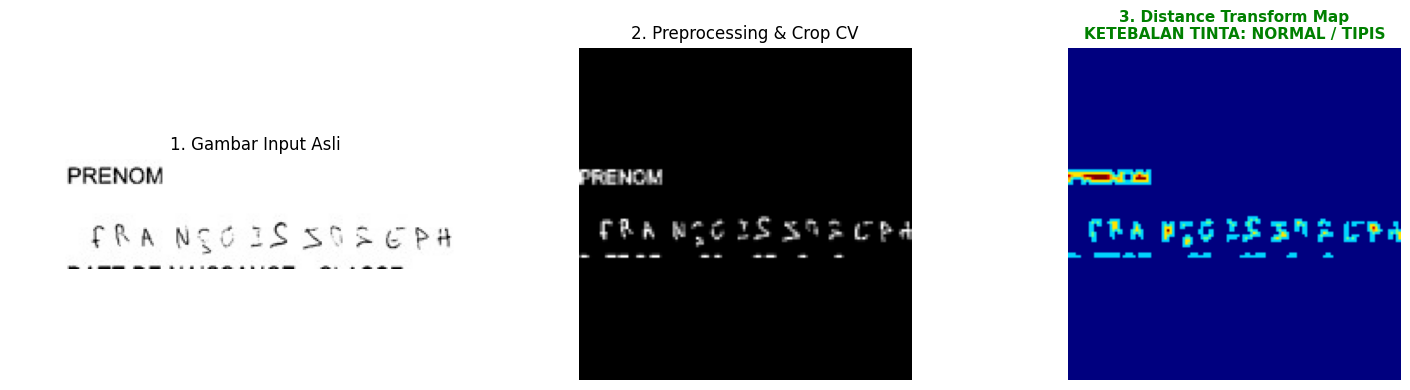

HASIL PREDIKSI MODEL SVM KETEBALAN TINTA:
KLASIFIKASI MODEL SVM : KETEBALAN TINTA: NORMAL / TIPIS


In [45]:
print("Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nMemproses Analisis SVM Ketebalan Tinta: {filename} ...")
    analyze_ink_thickness_svm(filename)

Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:


Saving c02-000-02-06.png to c02-000-02-06 (1).png

Memproses Analisis SVM Ketebalan Tinta: c02-000-02-06 (1).png ...


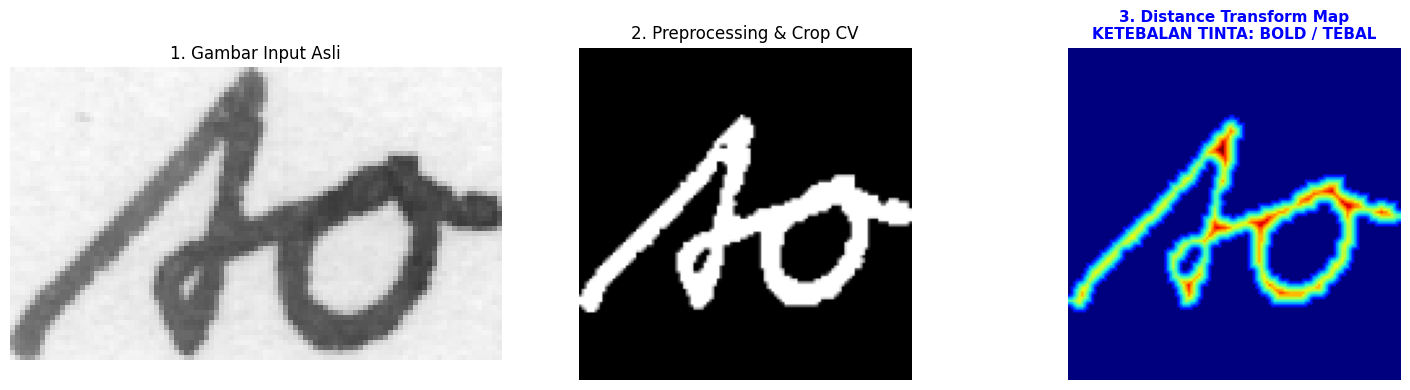

HASIL PREDIKSI MODEL SVM KETEBALAN TINTA:
KLASIFIKASI MODEL SVM : KETEBALAN TINTA: BOLD / TEBAL


In [46]:
print("Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nMemproses Analisis SVM Ketebalan Tinta: {filename} ...")
    analyze_ink_thickness_svm(filename)

Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:


Saving dokter1.png to dokter1 (3).png

Memproses Analisis SVM Ketebalan Tinta: dokter1 (3).png ...


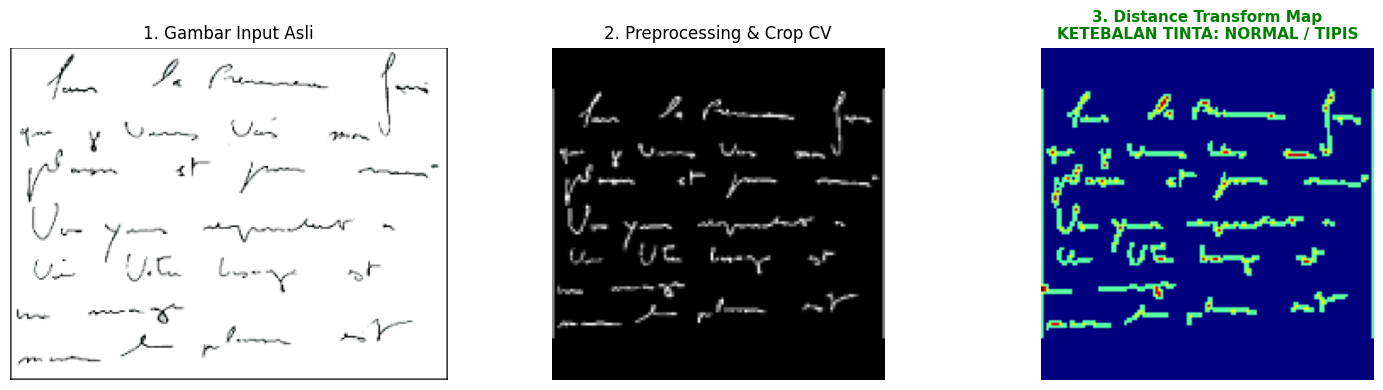

HASIL PREDIKSI MODEL SVM KETEBALAN TINTA:
KLASIFIKASI MODEL SVM : KETEBALAN TINTA: NORMAL / TIPIS


In [47]:
print("Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nMemproses Analisis SVM Ketebalan Tinta: {filename} ...")
    analyze_ink_thickness_svm(filename)


Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:


Saving unreadable1.webp to unreadable1.webp

Memproses Analisis SVM Ketebalan Tinta: unreadable1.webp ...


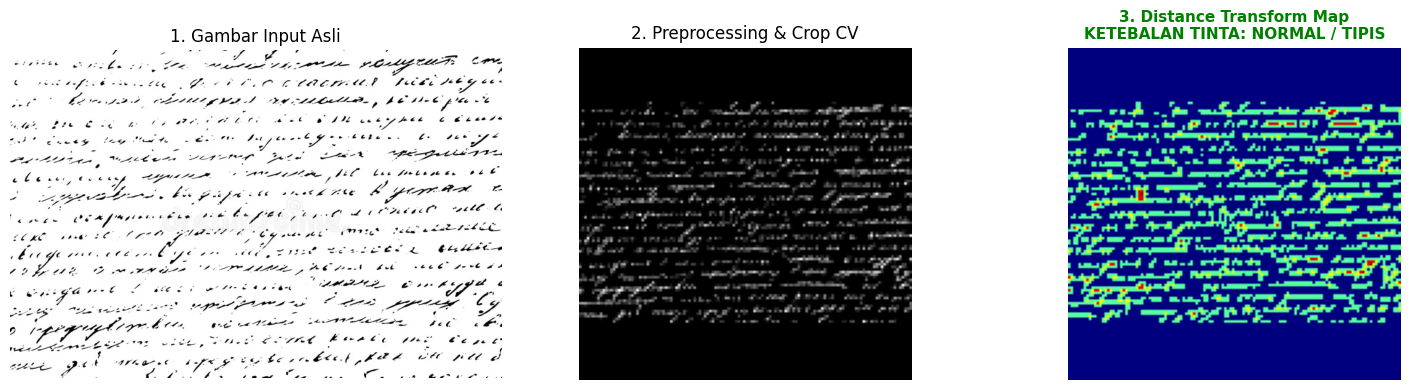

HASIL PREDIKSI MODEL SVM KETEBALAN TINTA:
KLASIFIKASI MODEL SVM : KETEBALAN TINTA: NORMAL / TIPIS


In [48]:
print("Silakan upload file gambar tulisan tangan (.png / .jpg / .webp) dari komputer Anda:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nMemproses Analisis SVM Ketebalan Tinta: {filename} ...")
    analyze_ink_thickness_svm(filename)
